In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# - Paths -------------------------------------------------
RF_DIR  = "random_forest"
KNN_DIR = "knn"
XGB_DIR = "xgboost"
OUT_DIR = "feature_agreement"
TOP_K   = 10          # for top-k overlap analysis

os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
# Load all SHAP importance CSVs 
def load_importance(base_dir, model_tag, crop_name):
    pattern = os.path.join(
        base_dir,
        f"{crop_name}_{model_tag}",
        f"{crop_name}_shap_importance_{model_tag}.csv"
    )
    matches = glob.glob(pattern)
    if not matches:
        return None
    df = pd.read_csv(matches[0])
    return df.set_index("feature")["importance"]

# Load per-crop accuracy metrics from summary CSVs 
def load_summary(base_dir, model_tag):
    path = os.path.join(base_dir, f"all_crops_summary_{model_tag}.csv")
    if not os.path.exists(path):
        return {}
    df = pd.read_csv(path)
    # weight = average of CV accuracy and CV F1
    df["weight_raw"] = (df["acc_mean"] + df["f1_mean"]) / 2
    return df.set_index("crop")["weight_raw"].to_dict()

MODELS = {
    "random_forest": (RF_DIR,  "random_forest"),
    "knn":           (KNN_DIR, "knn"),
    "xgboost":       (XGB_DIR, "xgboost"),
}

# Load accuracy weights per model per crop
model_weights_raw = {
    mname: load_summary(mdir, mtag)
    for mname, (mdir, mtag) in MODELS.items()
}

print("Accuracy-based weights loaded (avg of acc_mean + f1_mean):")
for mname, wd in model_weights_raw.items():
    print(f"  {mname}: {len(wd)} crops found")

# Discover crops from RF
rf_crop_dirs = glob.glob(os.path.join(RF_DIR, "*_random_forest"))
crop_names   = sorted([
    os.path.basename(d).replace("_random_forest", "")
    for d in rf_crop_dirs
])
print(f"\nFound {len(crop_names)} crops: {crop_names}")

Accuracy-based weights loaded (avg of acc_mean + f1_mean):
  random_forest: 43 crops found
  knn: 43 crops found
  xgboost: 43 crops found

Found 54 crops: ['arecanut', 'arhar_tur', 'bajra', 'banana', 'barley', 'black_pepper', 'cardamom', 'cashewnut', 'castorseed', 'coconut', 'coriander', 'cotton', 'cowpea_lobia', 'dry_chillies', 'garlic', 'ginger', 'gram', 'groundnut', 'guar_seed', 'horse_gram', 'jowar', 'jute', 'khesari', 'linseed', 'maize', 'masoor', 'mesta', 'moong', 'moth', 'niger_seed', 'onion', 'other_cereals', 'other_kharif_pulses', 'other_oilseeds', 'other_rabi_pulses', 'other_summer_pulses', 'peas_and_beans', 'potato', 'ragi', 'rapeseed_and_mustard', 'rice', 'safflower', 'sannhamp', 'sesamum', 'small_millets', 'soyabean', 'sugarcane', 'sunflower', 'sweet_potato', 'tapioca', 'tobacco', 'turmeric', 'urad', 'wheat']


In [24]:
# Per-crop: Spearman + top-k overlap + weighted Borda 
MODEL_PAIRS = [
    ("random_forest", "knn"),
    ("random_forest", "xgboost"),
    ("knn",           "xgboost"),
]

summary_rows     = []
borda_all        = {}   # crop -> unweighted borda Series
borda_weighted   = {}   # crop -> weighted borda Series
model_weights_df = []   # for inspection

for crop in crop_names:
    print(f"\n{'='*55}")
    print(f"CROP: {crop}")
    print(f"{'='*55}")

    # Load importances
    imp = {}
    for mname, (mdir, mtag) in MODELS.items():
        s = load_importance(mdir, mtag, crop)
        if s is not None:
            imp[mname] = s
        else:
            print(f"  [WARN] Missing SHAP CSV for {mname}")

    if len(imp) < 2:
        print("  Skipping - fewer than 2 models available")
        continue

    # Resolve accuracy weights for this crop
    raw_w = {}
    for mname in imp:
        w = model_weights_raw[mname].get(crop, None)
        if w is None:
            print(f"  [WARN] No accuracy data for {mname} on {crop} - using equal weight")
            w = 1.0
        raw_w[mname] = w

    # Normalize weights so they sum to 1 across available models
    total_w = sum(raw_w.values())
    norm_w  = {m: v / total_w for m, v in raw_w.items()}

    print(f"\n  Model weights (normalized avg of acc+f1):")
    for mname, w in norm_w.items():
        print(f"    {mname:<18}  raw={raw_w[mname]:.4f}  normalized={w:.4f}")

    model_weights_df.append({
        "crop": crop,
        **{f"weight_{m}": round(norm_w[m], 4) for m in norm_w},
        **{f"raw_weight_{m}": round(raw_w[m], 4) for m in raw_w},
    })

    # Common features & ranks
    common_features = list(
        set.intersection(*[set(s.index) for s in imp.values()])
    )
    print(f"\n  Common features: {len(common_features)}")

    if len(common_features) < 3:
        print("  Skipping - too few common features")
        continue

    ranks = {}
    for mname, s in imp.items():
        s_common = s.reindex(common_features).fillna(0)
        ranks[mname] = s_common.rank(ascending=False, method="average")

    row = {"crop": crop, "n_common_features": len(common_features)}
    for mname, w in norm_w.items():
        row[f"weight_{mname}"] = round(w, 4)

    # Pairwise Spearman
    print(f"\n  Pairwise Spearman rank correlations:")
    for m1, m2 in MODEL_PAIRS:
        if m1 not in ranks or m2 not in ranks:
            continue
        rho, pval = spearmanr(ranks[m1], ranks[m2])
        label = f"spearman_{m1}_vs_{m2}"
        row[label]           = round(rho,  4)
        row[label + "_pval"] = round(pval, 4)
        print(f"    {m1:>14} vs {m2:<14}  rho={rho:.4f}  p={pval:.4f}")

    rho_vals = [row[f"spearman_{m1}_vs_{m2}"]
                for m1, m2 in MODEL_PAIRS
                if f"spearman_{m1}_vs_{m2}" in row]
    row["spearman_mean"] = round(np.mean(rho_vals), 4)
    print(f"    Mean rho: {row['spearman_mean']:.4f}")

    # Top-k overlap
    k = min(TOP_K, len(common_features))
    topk = {}
    for mname, s in imp.items():
        s_common = s.reindex(common_features).fillna(0)
        topk[mname] = set(s_common.nlargest(k).index)

    print(f"\n  Top-{k} overlap:")
    for m1, m2 in MODEL_PAIRS:
        if m1 not in topk or m2 not in topk:
            continue
        overlap = len(topk[m1] & topk[m2])
        pct     = overlap / k
        label   = f"topk_{m1}_vs_{m2}"
        row[label]            = overlap
        #row[label + "_pct"]   = round(pct, 4)
        print(f"    {m1:>14} vs {m2:<14}  {overlap}/{k} ({pct*100:.1f}%)")

    all_topk = set.intersection(*topk.values()) if len(topk) == 3 else set()
    row["topk_all3_count"] = len(all_topk)
    print(f"    In top-{k} for ALL 3 models: {sorted(all_topk)}")

    # Unweighted Borda
    borda_scores = pd.DataFrame(ranks).mean(axis=1).sort_values()
    borda_all[crop] = borda_scores

    # Weighted Borda
    # weighted_rank_feature = sum(weight_m * rank_m)  ->  lower = more important
    ranks_df   = pd.DataFrame(ranks)          # features x models
    weights_arr = pd.Series(norm_w)           # model -> normalized weight
    # align columns
    weights_arr = weights_arr.reindex(ranks_df.columns)
    weighted_scores = ranks_df.mul(weights_arr, axis=1).sum(axis=1).sort_values()
    borda_weighted[crop] = weighted_scores

    print(f"\n  Weighted Borda top-10  (weight = normalized avg(acc, f1)):")
    print(f"    {'Feature':<35} {'Wtd Score':>10}  {'Unwtd Score':>12}")
    for feat in weighted_scores.head(10).index:
        print(f"    {feat:<35} {weighted_scores[feat]:>10.3f}  {borda_scores[feat]:>12.3f}")

    # Save per-crop CSVs (both unweighted and weighted)
    out = pd.DataFrame({
        "feature":        common_features,
        "unweighted_avg_rank": [borda_scores[f]   for f in common_features],
        "weighted_avg_rank":   [weighted_scores[f] for f in common_features],
    })
    out["unweighted_rank"] = out["unweighted_avg_rank"].rank().astype(int)
    out["weighted_rank"]   = out["weighted_avg_rank"].rank().astype(int)
    out = out.sort_values("weighted_avg_rank")
    out.to_csv(os.path.join(OUT_DIR, f"{crop}_borda_consensus.csv"), index=False)

    summary_rows.append(row)

summary_df      = pd.DataFrame(summary_rows).sort_values("spearman_mean", ascending=False)
weights_log_df  = pd.DataFrame(model_weights_df)

summary_df.to_csv(os.path.join(OUT_DIR, "agreement_summary.csv"), index=False)
weights_log_df.to_csv(os.path.join(OUT_DIR, "model_weights_per_crop.csv"), index=False)
print(f"\nSummary saved -> {OUT_DIR}/agreement_summary.csv")
print(f"Weights log  -> {OUT_DIR}/model_weights_per_crop.csv")


CROP: arecanut
  [WARN] Missing SHAP CSV for random_forest
  [WARN] Missing SHAP CSV for knn
  [WARN] Missing SHAP CSV for xgboost
  Skipping - fewer than 2 models available

CROP: arhar_tur

  Model weights (normalized avg of acc+f1):
    random_forest       raw=0.5714  normalized=0.2917
    knn                 raw=0.6890  normalized=0.3517
    xgboost             raw=0.6985  normalized=0.3566

  Common features: 36

  Pairwise Spearman rank correlations:
     random_forest vs knn             rho=0.3598  p=0.0311
     random_forest vs xgboost         rho=0.7408  p=0.0000
               knn vs xgboost         rho=0.4692  p=0.0039
    Mean rho: 0.5233

  Top-10 overlap:
     random_forest vs knn             3/10 (30.0%)
     random_forest vs xgboost         6/10 (60.0%)
               knn vs xgboost         5/10 (50.0%)
    In top-10 for ALL 3 models: ['GDD_rabi', 'e_zaid_mean', 'runoff_ratio_rabi_mean']

  Weighted Borda top-10  (weight = normalized avg(acc, f1)):
    Feature         

In [14]:
print("\nAGREEMENT SUMMARY (sorted by mean Spearman rho)")
print("="*90)
display_cols = [
    "crop", "n_common_features", "spearman_mean",
    "spearman_random_forest_vs_knn",
    "spearman_random_forest_vs_xgboost",
    "spearman_knn_vs_xgboost",
    "topk_all3_count",
    "weight_random_forest", "weight_knn", "weight_xgboost",
]
display_cols = [c for c in display_cols if c in summary_df.columns]
print(summary_df[display_cols].to_string(index=False))

print(f"\nOverall mean Spearman rho: {summary_df['spearman_mean'].mean():.4f}  "
      f"SD: {summary_df['spearman_mean'].std():.4f}")


AGREEMENT SUMMARY (sorted by mean Spearman rho)
                crop  n_common_features  spearman_mean  spearman_random_forest_vs_knn  spearman_random_forest_vs_xgboost  spearman_knn_vs_xgboost  topk_all3_count  weight_random_forest  weight_knn  weight_xgboost
               mesta                 36         0.7075                         0.7302                             0.7887                   0.6036                5                0.3297      0.3350          0.3352
            turmeric                 36         0.6757                         0.5951                             0.8358                   0.5961                6                0.3277      0.3375          0.3347
      other_oilseeds                 36         0.6219                         0.6031                             0.7127                   0.5498                6                0.3358      0.3301          0.3341
       small_millets                 36         0.5908                         0.4579              

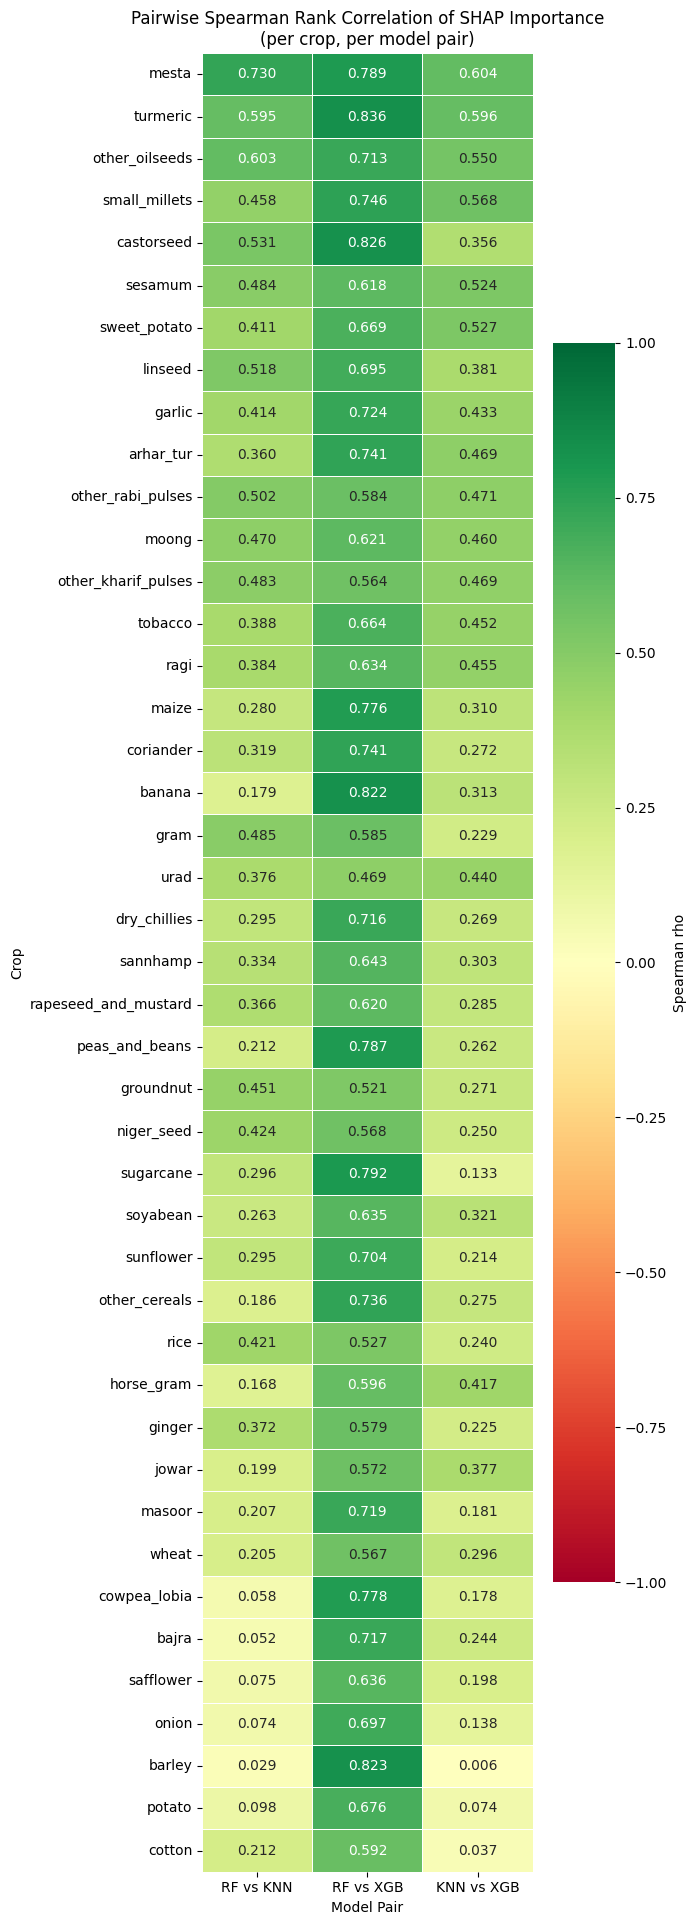

Saved -> spearman_heatmap.png


In [16]:
# Plot 1: Pairwise Spearman heatmap
pair_cols = {
    "RF vs KNN":  "spearman_random_forest_vs_knn",
    "RF vs XGB":  "spearman_random_forest_vs_xgboost",
    "KNN vs XGB": "spearman_knn_vs_xgboost",
}
pair_cols = {k: v for k, v in pair_cols.items() if v in summary_df.columns}
heatmap_data = summary_df.set_index("crop")[[*pair_cols.values()]].rename(
    columns={v: k for k, v in pair_cols.items()}
)
fig, ax = plt.subplots(figsize=(7, max(4, len(heatmap_data) * 0.45)))
sns.heatmap(
    heatmap_data, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Spearman rho"}
)
ax.set_title("Pairwise Spearman Rank Correlation of SHAP Importance\n(per crop, per model pair)", fontsize=12)
ax.set_ylabel("Crop"); ax.set_xlabel("Model Pair")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "spearman_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> spearman_heatmap.png")

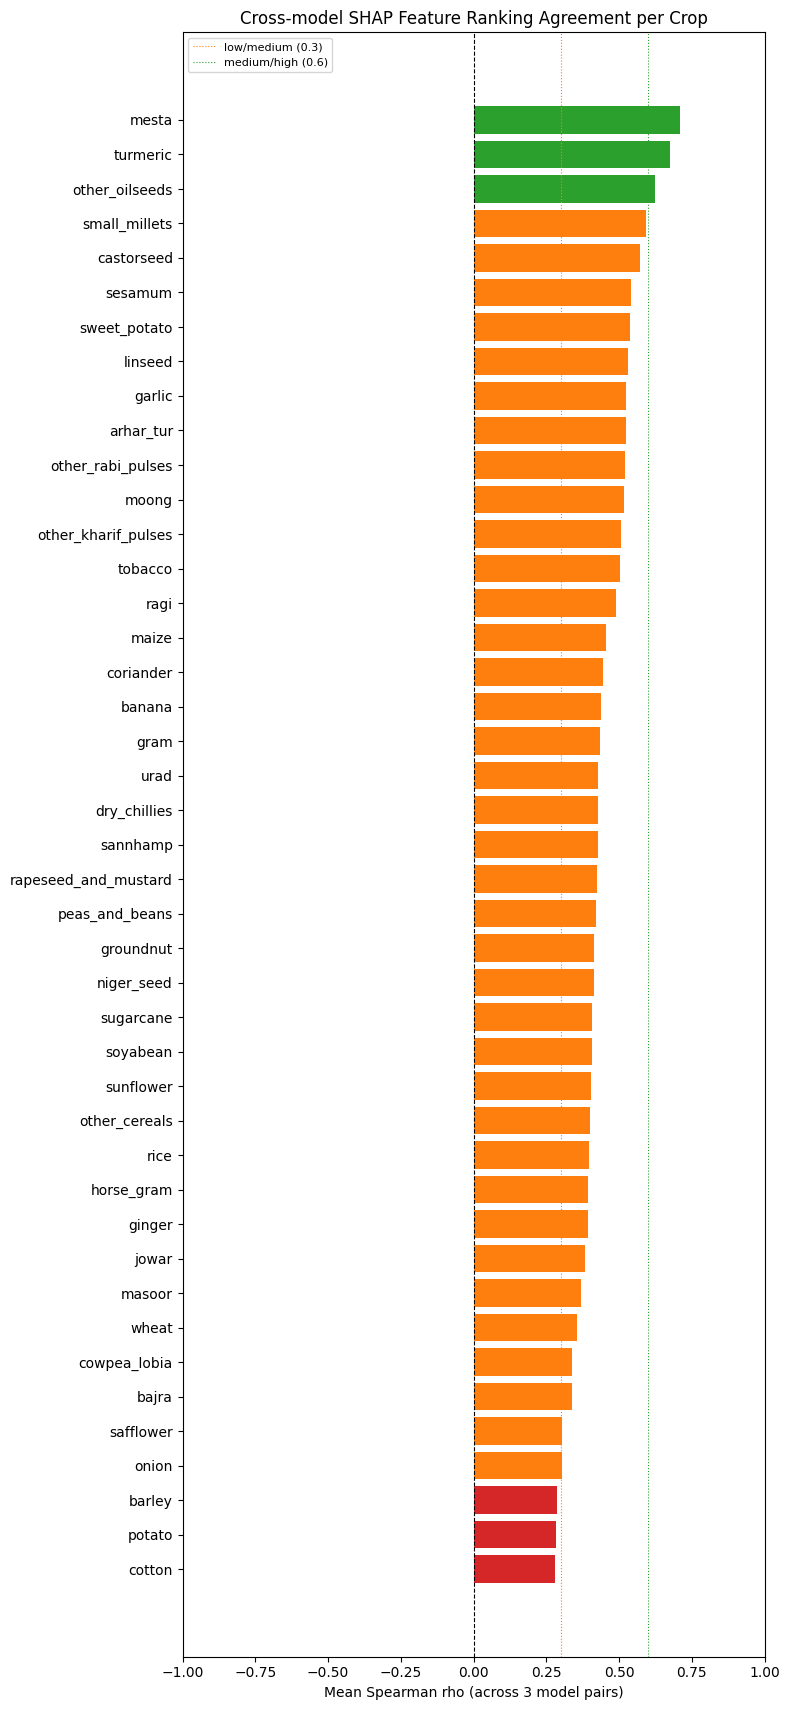

Saved -> spearman_per_crop.png


In [17]:
# Plot 2: Mean Spearman per crop (bar)
fig, ax = plt.subplots(figsize=(8, max(4, len(summary_df) * 0.4)))
colors = ["#d62728" if v < 0.3 else "#ff7f0e" if v < 0.6 else "#2ca02c"
          for v in summary_df["spearman_mean"]]
ax.barh(summary_df["crop"], summary_df["spearman_mean"], color=colors)
ax.axvline(0,   color="black",    linewidth=0.8, linestyle="--")
ax.axvline(0.3, color="#ff7f0e",  linewidth=0.8, linestyle=":", label="low/medium (0.3)")
ax.axvline(0.6, color="#2ca02c",  linewidth=0.8, linestyle=":", label="medium/high (0.6)")
ax.set_xlim(-1, 1)
ax.set_xlabel("Mean Spearman rho (across 3 model pairs)")
ax.set_title("Cross-model SHAP Feature Ranking Agreement per Crop")
ax.legend(fontsize=8); ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "spearman_per_crop.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> spearman_per_crop.png")

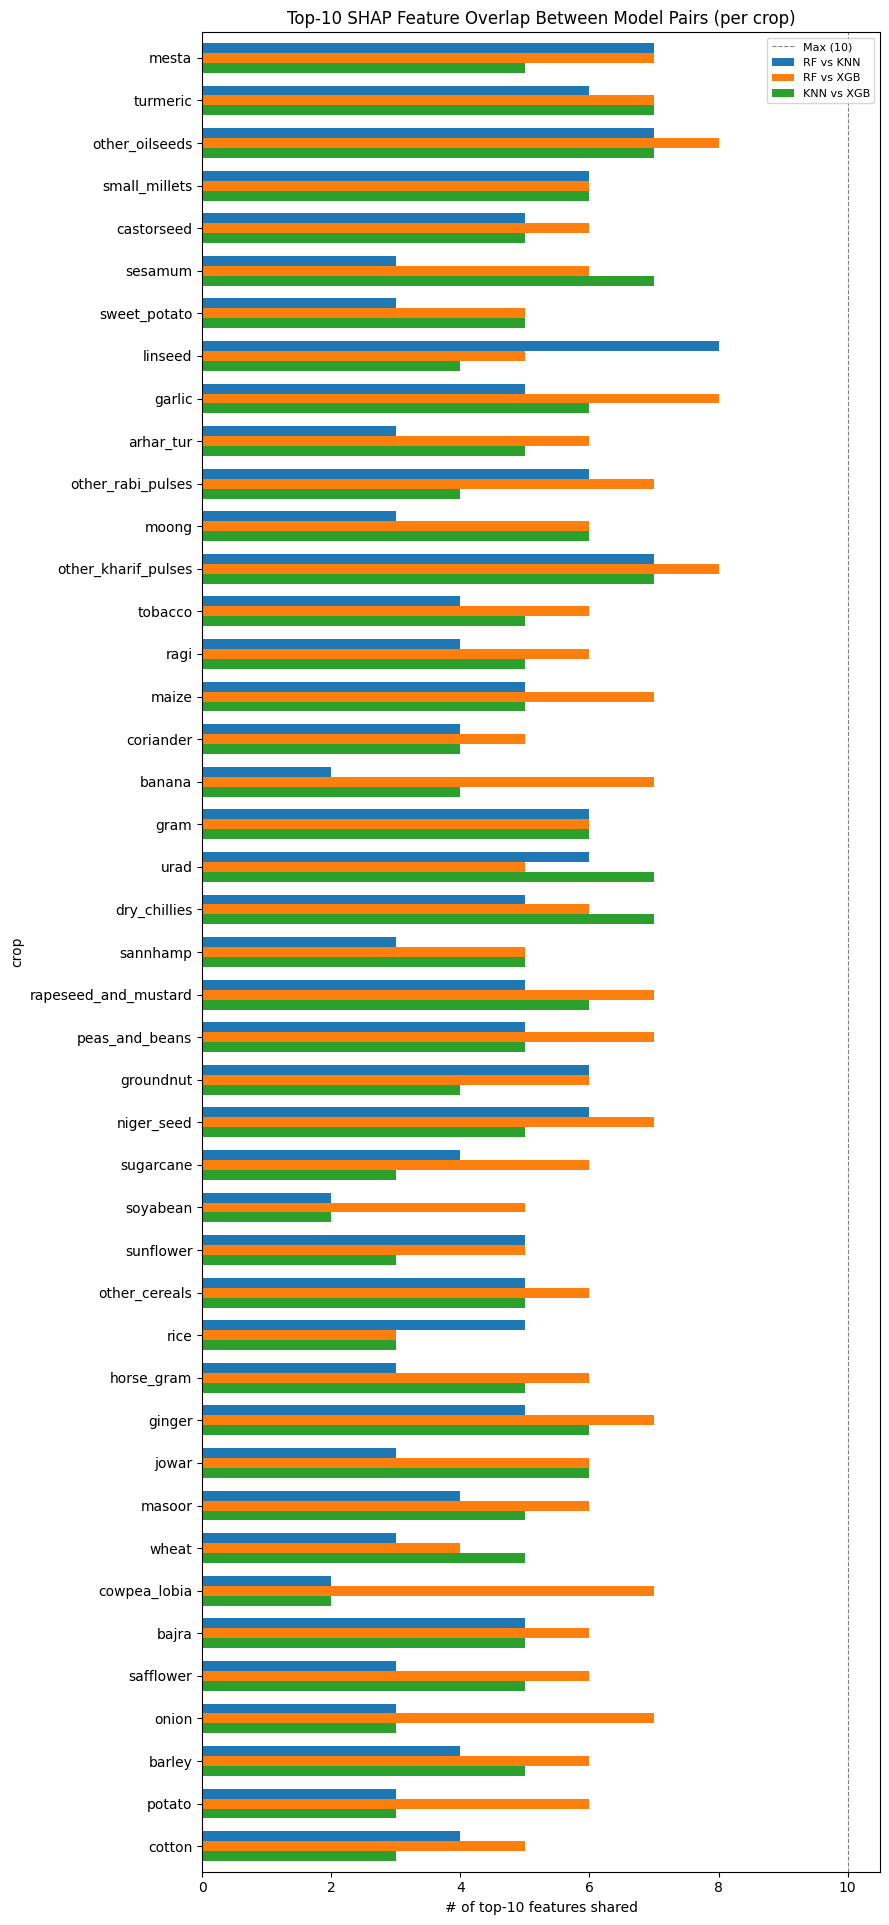

Saved -> topk_overlap.png


In [18]:
# Plot 3: Top-k overlap per crop
topk_pair_cols = {
    "RF vs KNN":  "topk_random_forest_vs_knn",
    "RF vs XGB":  "topk_random_forest_vs_xgboost",
    "KNN vs XGB": "topk_knn_vs_xgboost",
}
topk_pair_cols = {k: v for k, v in topk_pair_cols.items() if v in summary_df.columns}
if topk_pair_cols:
    topk_data = summary_df.set_index("crop")[[*topk_pair_cols.values()]].rename(
        columns={v: k for k, v in topk_pair_cols.items()}
    )
    fig, ax = plt.subplots(figsize=(9, max(4, len(topk_data) * 0.45)))
    topk_data.plot(kind="barh", ax=ax, width=0.7)
    ax.axvline(TOP_K, color="gray", linestyle="--", linewidth=0.8, label=f"Max ({TOP_K})")
    ax.set_xlabel(f"# of top-{TOP_K} features shared")
    ax.set_title(f"Top-{TOP_K} SHAP Feature Overlap Between Model Pairs (per crop)")
    ax.legend(fontsize=8); ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "topk_overlap.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved -> topk_overlap.png")

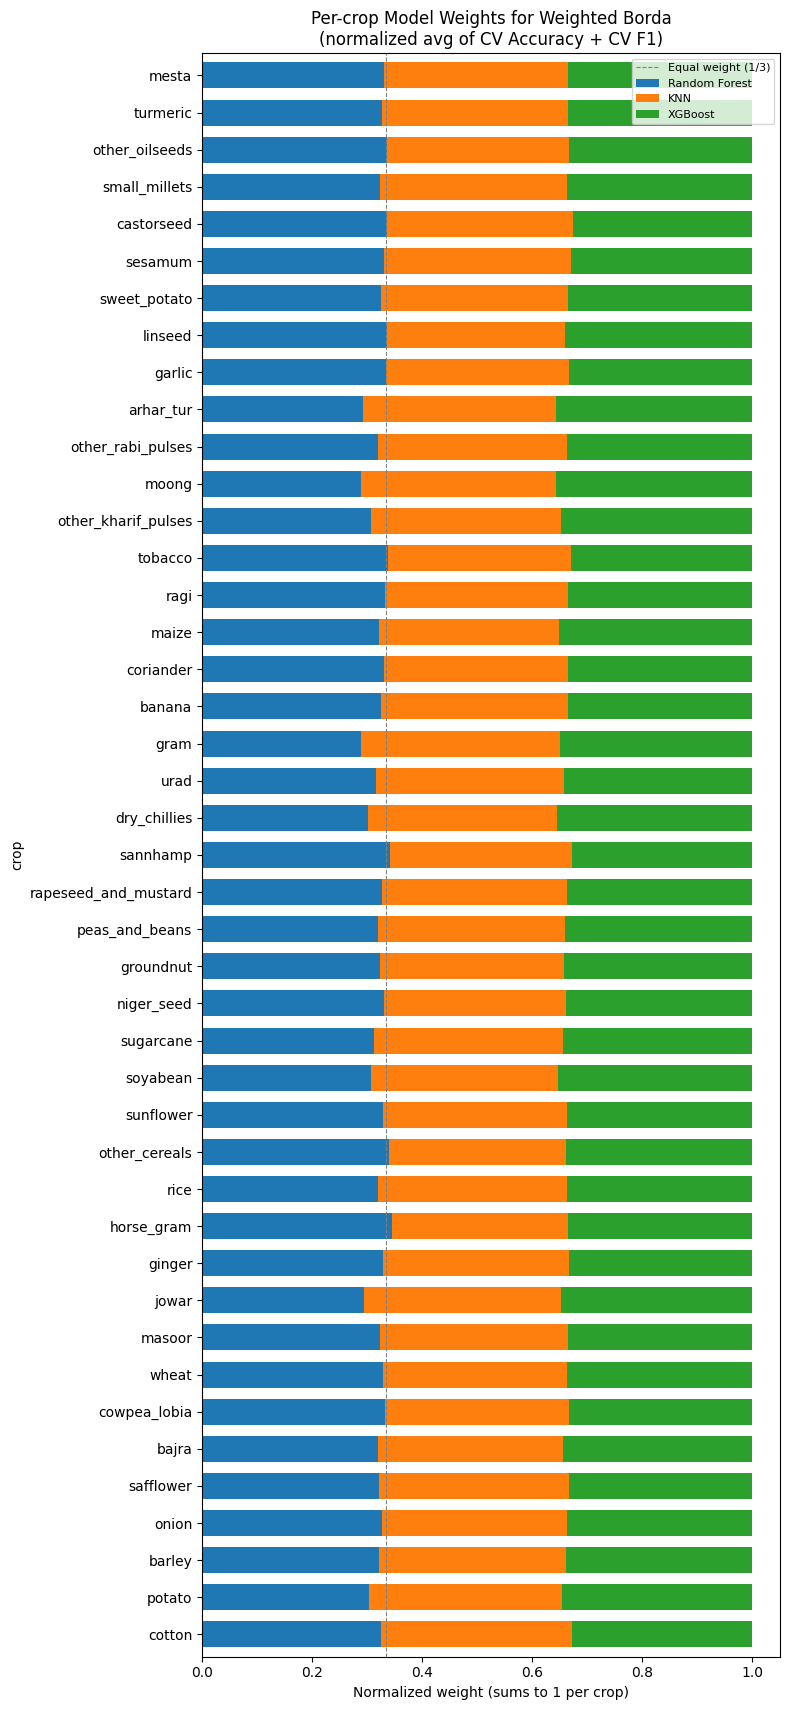

Saved -> model_weights.png


In [19]:
# Plot 4: Model weights per crop (stacked bar)
weight_cols = {
    "Random Forest": "weight_random_forest",
    "KNN":           "weight_knn",
    "XGBoost":       "weight_xgboost",
}
weight_cols = {k: v for k, v in weight_cols.items() if v in summary_df.columns}
if weight_cols:
    wdata = summary_df.set_index("crop")[[*weight_cols.values()]].rename(
        columns={v: k for k, v in weight_cols.items()}
    )
    fig, ax = plt.subplots(figsize=(8, max(4, len(wdata) * 0.4)))
    wdata.plot(kind="barh", stacked=True, ax=ax,
               color=["#1f77b4", "#ff7f0e", "#2ca02c"], width=0.7)
    ax.axvline(1/3, color="gray", linestyle="--", linewidth=0.8, label="Equal weight (1/3)")
    ax.set_xlabel("Normalized weight (sums to 1 per crop)")
    ax.set_title("Per-crop Model Weights for Weighted Borda\n(normalized avg of CV Accuracy + CV F1)")
    ax.legend(fontsize=8); ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "model_weights.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved -> model_weights.png")


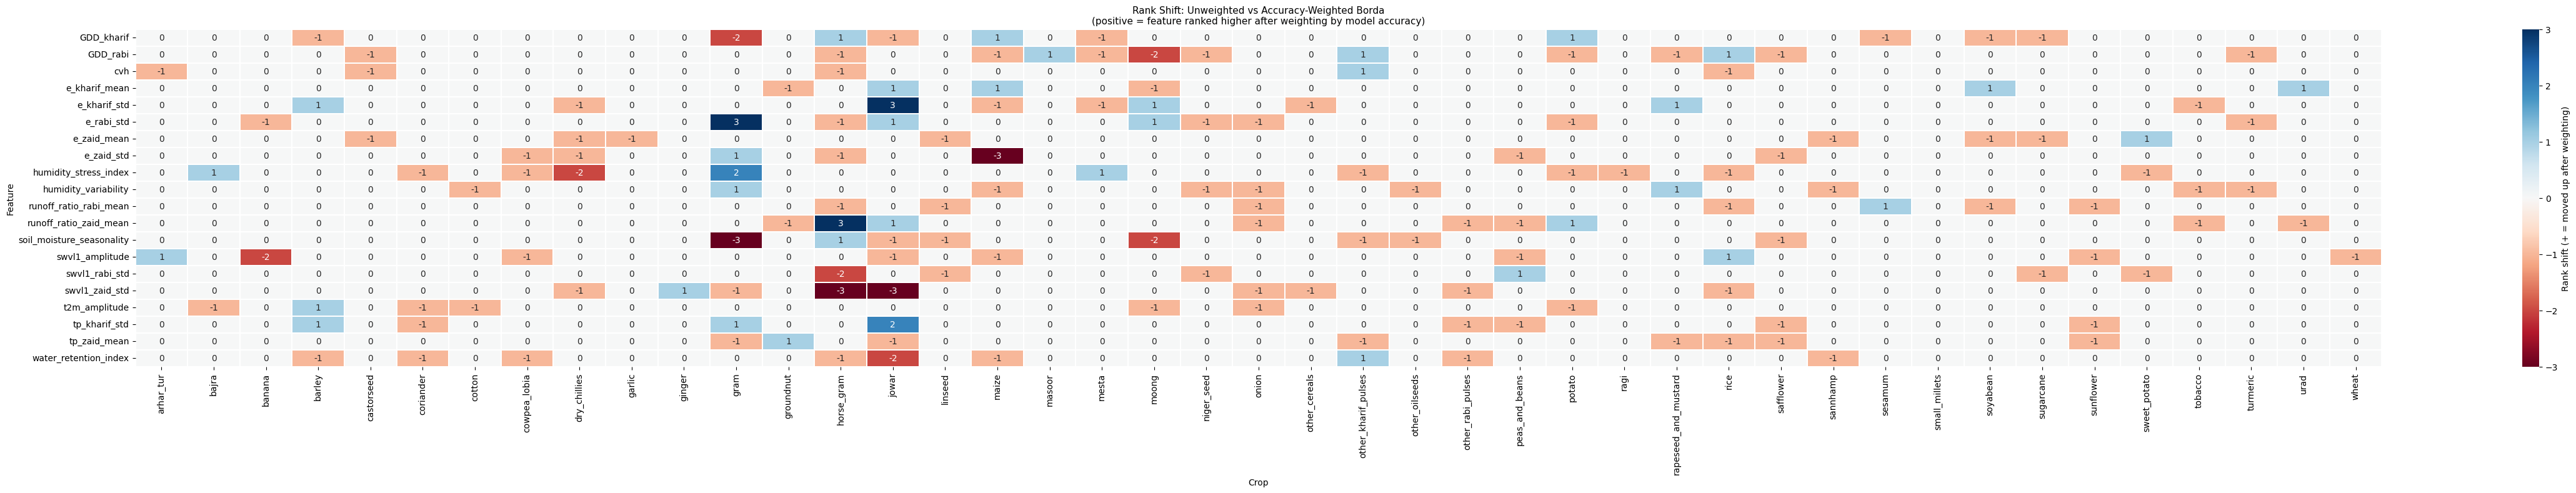

Saved -> borda_rank_shift.png


In [20]:
# Plot 5: Weighted vs Unweighted Borda rank shift heatmap
# For each crop, show rank change (unweighted_rank - weighted_rank) for top-15 features
shift_frames = []
for crop in borda_weighted:
    df = pd.read_csv(os.path.join(OUT_DIR, f"{crop}_borda_consensus.csv"))
    df["crop"] = crop
    shift_frames.append(df)

if shift_frames:
    all_borda = pd.concat(shift_frames, ignore_index=True)
    all_borda["rank_shift"] = all_borda["unweighted_rank"] - all_borda["weighted_rank"]

    # Top-15 weighted features per crop, then pivot
    top_features = (
        all_borda.sort_values("weighted_rank")
        .groupby("crop")
        .head(15)["feature"]
        .value_counts()
        .head(20)
        .index.tolist()
    )
    pivot = all_borda[all_borda["feature"].isin(top_features)].pivot(
        index="feature", columns="crop", values="rank_shift"
    ).fillna(0)

    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 1.1), max(5, len(pivot) * 0.4)))
    sns.heatmap(
        pivot, annot=True, fmt=".0f", cmap="RdBu", center=0,
        linewidths=0.3, ax=ax,
        cbar_kws={"label": "Rank shift (+ = moved up after weighting)"}
    )
    ax.set_title("Rank Shift: Unweighted vs Accuracy-Weighted Borda\n"
                 "(positive = feature ranked higher after weighting by model accuracy)", fontsize=11)
    ax.set_xlabel("Crop"); ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "borda_rank_shift.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved -> borda_rank_shift.png")

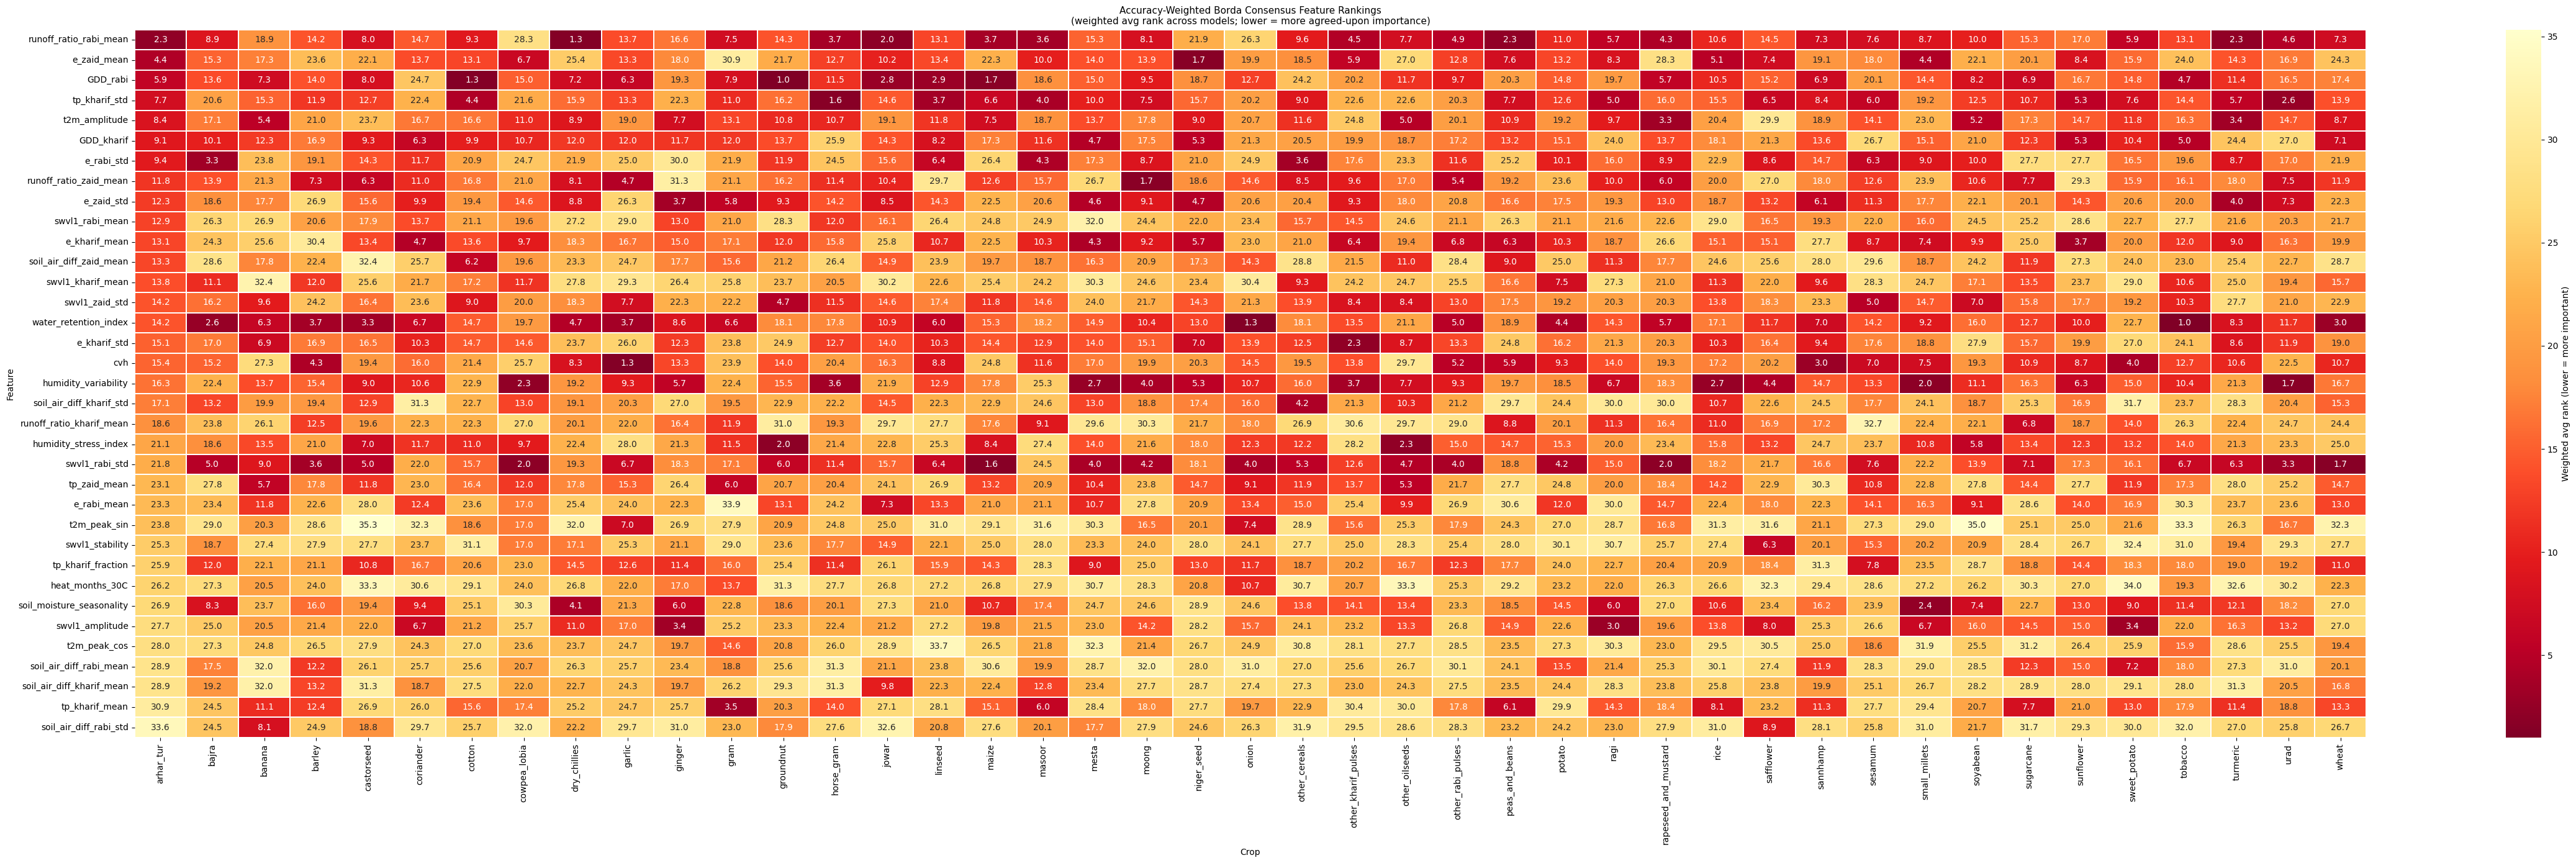

Saved -> borda_weighted_heatmap.png


In [21]:
# Plot 6: Borda consensus heatmap (weighted, top-15 features x crops)
borda_matrix_w   = pd.DataFrame({c: borda_weighted[c] for c in borda_weighted}).fillna(999)
borda_matrix_unw = pd.DataFrame({c: borda_all[c]      for c in borda_all     }).fillna(999)

top15_features = set()
for crop in borda_weighted:
    top15_features.update(borda_weighted[crop].head(15).index.tolist())

borda_sub = borda_matrix_w.loc[sorted(top15_features)].sort_values(
    by=list(borda_matrix_w.columns), ascending=True
)
fig, ax = plt.subplots(figsize=(max(8, len(borda_sub.columns) * 1.1), max(6, len(borda_sub) * 0.4)))
sns.heatmap(
    borda_sub, annot=True, fmt=".1f", cmap="YlOrRd_r",
    linewidths=0.3, ax=ax,
    cbar_kws={"label": "Weighted avg rank (lower = more important)"}
)
ax.set_title("Accuracy-Weighted Borda Consensus Feature Rankings\n"
             "(weighted avg rank across models; lower = more agreed-upon importance)", fontsize=11)
ax.set_xlabel("Crop"); ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "borda_weighted_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> borda_weighted_heatmap.png")


Top 20 features most consistently important across ALL crops and ALL models
(ranked by accuracy-weighted Borda):
                  feature  weighted_mean_rank  unweighted_mean_rank  weighted_global_rank  unweighted_global_rank  global_rank_shift
   runoff_ratio_rabi_mean           10.001871             10.031008                     1                       1                  0
    water_retention_index           10.849928             10.891473                     2                       2                  0
           swvl1_rabi_std           10.851483             10.937984                     3                       3                  0
                 GDD_rabi           11.978618             11.945736                     4                       4                  0
            tp_kharif_std           12.169931             12.232558                     5                       6                  1
     humidity_variability           12.205728             12.209302                     6

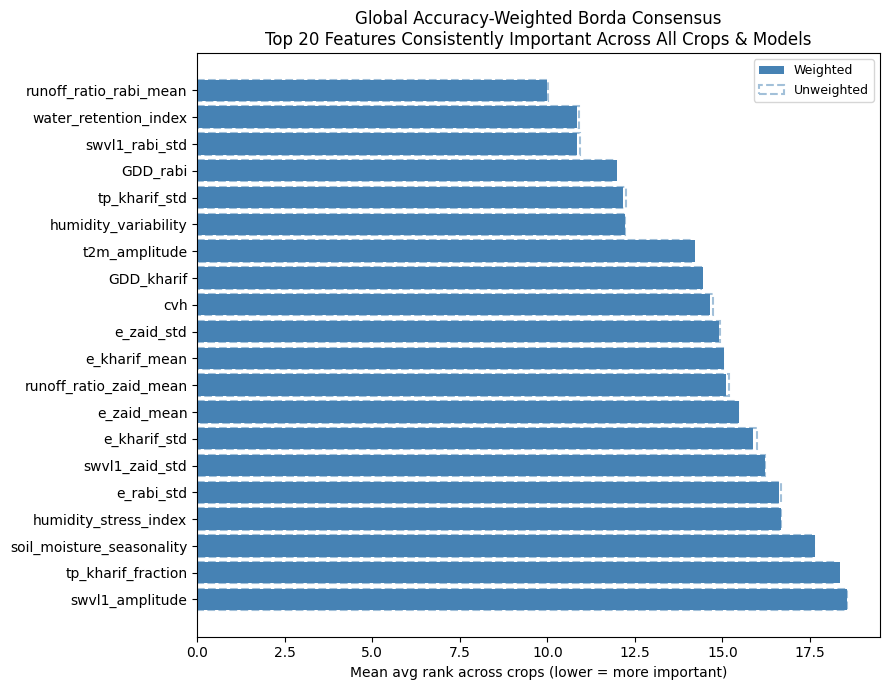


Full global consensus -> feature_agreement/global_borda_consensus.csv


In [22]:
# Global weighted Borda consensus (across ALL crops)
n_features_global = borda_matrix_w.shape[0]
global_borda_w   = borda_matrix_w.replace(999, n_features_global).mean(axis=1).sort_values()
global_borda_unw = borda_matrix_unw.replace(999, n_features_global).mean(axis=1).sort_values()

global_df = pd.DataFrame({
    "feature":               global_borda_w.index,
    "weighted_mean_rank":    global_borda_w.values,
    "unweighted_mean_rank":  global_borda_unw.reindex(global_borda_w.index).values,
}).reset_index(drop=True)
global_df["weighted_global_rank"]   = range(1, len(global_df) + 1)
global_df["unweighted_global_rank"] = global_df["unweighted_mean_rank"].rank().astype(int)
global_df["global_rank_shift"]      = global_df["unweighted_global_rank"] - global_df["weighted_global_rank"]
global_df.to_csv(os.path.join(OUT_DIR, "global_borda_consensus.csv"), index=False)

print("Top 20 features most consistently important across ALL crops and ALL models")
print("(ranked by accuracy-weighted Borda):")
print(global_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
top20 = global_df.head(20)
bars = ax.barh(top20["feature"], top20["weighted_mean_rank"], color="steelblue", label="Weighted")
ax.barh(top20["feature"], top20["unweighted_mean_rank"], color="lightsteelblue",
        alpha=0.5, label="Unweighted", linestyle="--", linewidth=1.5, fill=False,
        edgecolor="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Mean avg rank across crops (lower = more important)")
ax.set_title("Global Accuracy-Weighted Borda Consensus\n"
             "Top 20 Features Consistently Important Across All Crops & Models")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "global_borda_top20.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFull global consensus -> {OUT_DIR}/global_borda_consensus.csv")